In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.plot_styles import *

In [23]:
input_filename = 'Grid/grid_128_64.csv'

In [24]:
def GetSolutionDict(input_filename):
    # Read the first three lines to extract grid sizes
    with open(input_filename, 'r') as f:
        ndim = int(f.readline().strip().split('=')[1])
        ni = int(f.readline().strip().split('=')[1])
        nj = int(f.readline().strip().split('=')[1])
        nk = int(f.readline().strip().split('=')[1])
    
    df = pd.read_csv(input_filename, skiprows=4)
    data_dict = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}
    return data_dict

    
data_dict = GetSolutionDict(input_filename)

In [25]:
data_dict.keys()

dict_keys(['x', 'y', 'z'])

In [26]:
data_dict['ax'] = data_dict['x'][:,:,0]
data_dict['r'] = np.sqrt(data_dict['y'][:,:,0]**2 + data_dict['z'][:,:,0]**2)

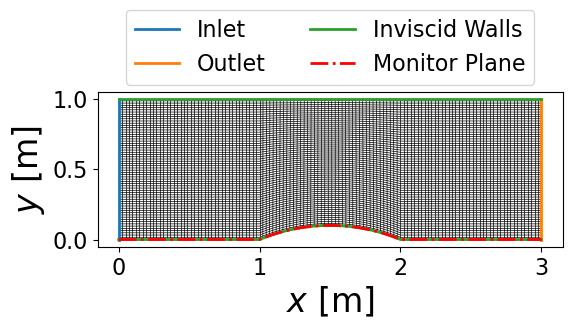

In [36]:
ni,nj = data_dict['ax'].shape
figsize = (6, 4)
lw = 0.5
plt.figure(figsize=figsize)
skip = 1
for i in range(0, ni, skip):
    plt.plot(data_dict['ax'][i,:], data_dict['r'][i,:], 'k-', linewidth=lw)
for j in range(0, nj, skip):
    plt.plot(data_dict['ax'][:,j], data_dict['r'][:,j], 'k-', linewidth=lw)

plt.plot(data_dict['ax'][0,:], data_dict['r'][0,:], 'C0-', linewidth=2, label='Inlet')
plt.plot(data_dict['ax'][-1,:], data_dict['r'][-1,:], 'C1-', linewidth=2, label='Outlet')
plt.plot(data_dict['ax'][:,0], data_dict['r'][:,0], 'C2-', linewidth=2, label='Inviscid Walls')
plt.plot(data_dict['ax'][:,-1], data_dict['r'][:,-1], 'C2-', linewidth=2)
plt.plot(data_dict['ax'][:,0], data_dict['r'][:,0], 'r-.', linewidth=2, label='Monitor Plane')







plt.legend(ncol=2, bbox_to_anchor=(0.5, 1.6), loc='upper center')
# plt.legend(ncol=2, fontsize=14)
plt.xlabel(r'$x$ [m]')
plt.ylabel(r'$y$ [m]')
# plt.xlim(right=0.7)
plt.ylim(bottom=-.05)
# plt.title('(%i x %i)' % (ni, nj))
plt.gca().set_aspect('equal', adjustable='box')
plt.savefig('circularbump_grid.pdf', bbox_inches='tight')

In [28]:
ni,nj

(124, 64)